<a href="https://colab.research.google.com/github/NaraDaibes/Liver_damage_prediction/blob/Predictions-Of-Product-Sales/ZillowHome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zillow Home data analysis (Time Series)

## Part 1

In [ ]:
# Imports
import pandas as pd
!pip install pmdarima
from pmdarima.arima.utils import ndiffs, nsdiffs
import statsmodels.tsa.api as tsa
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.9 MB/s eta 0:00:00


In [ ]:
pfile='/content/drive/MyDrive/AXSOSACADEMY (1)/AXSOSACADEMY/06-AdvancedML/Week24/Data/zillow_home_values-zipcode.csv'
df=pd.read_csv(pfile)
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [ ]:
df.shape

(27442, 284)

* Convert the data to long form insteadof wide form

In [ ]:
melted = pd.melt(df, id_vars=['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName'],value_name='Home value',var_name="Date")
melted

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0
...,...,...,...,...,...,...,...,...,...,...,...
7546545,80190,30657,50160,zip,IA,IA,Martensdale,"Des Moines-West Des Moines, IA",Warren County,30112022,193591.0
7546546,65355,30657,18081,zip,PA,PA,Hellertown,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",Bucks County,30112022,376523.0
7546547,82217,30657,55366,zip,MN,MN,NaN,NaN,Sibley County,30112022,110082.0
7546548,80581,30657,51009,zip,IA,IA,Calumet,NaN,O Brien County,30112022,75810.0


* double check .melted work right

.shape of the new data frame = #rows*#column-(keptcolumns) , # columns+2

                             = 27442*284-9 , 9+2
                             = (7546550,11)   perfect!

                          


In [ ]:
melted['Date'] = pd.to_datetime(melted['Date'], format='%d%m%Y')
melted.info()
melted.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   RegionID    int64         
 1   SizeRank    int64         
 2   RegionName  int64         
 3   RegionType  object        
 4   StateName   object        
 5   State       object        
 6   City        object        
 7   Metro       object        
 8   CountyName  object        
 9   Date        datetime64[ns]
 10  Home value  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 633.3+ MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,2000-01-31,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,275983.0


In [ ]:
melted = melted.set_index("Date")
melted

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0
...,...,...,...,...,...,...,...,...,...,...
2022-11-30,80190,30657,50160,zip,IA,IA,Martensdale,"Des Moines-West Des Moines, IA",Warren County,193591.0
2022-11-30,65355,30657,18081,zip,PA,PA,Hellertown,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",Bucks County,376523.0
2022-11-30,82217,30657,55366,zip,MN,MN,NaN,NaN,Sibley County,110082.0


In [ ]:
melted.isna().sum()

,0
RegionID,0
SizeRank,0
RegionName,0
RegionType,0
StateName,0
State,0
City,381425
Metro,1645325
CountyName,0
Home value,1836376


## Data Preparation for Tableau

Filtering the data for specified states and years (2010-2020).

In [ ]:
states_to_keep = ['CA', 'WA', 'OR', 'AZ', 'NV']
filtered_data = melted[melted['State'].isin(states_to_keep)].copy()
filtered_data = filtered_data.loc['2010':'2020'].copy()
filtered_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home value
Date,,,,,,,,,,
2010-01-31,95992,5,90011,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,209250.0
2010-01-31,96361,8,91331,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,257372.0
2010-01-31,96193,9,90650,zip,CA,CA,Norwalk,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,296430.0
2010-01-31,96083,12,90201,zip,CA,CA,Bell,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,271829.0
2010-01-31,96816,13,92335,zip,CA,CA,Fontana,"Riverside-San Bernardino-Ontario, CA",San Bernardino County,156704.0


## Saving Data for Tableau

Saving the processed and filtered data to a CSV file for use in Tableau.

In [ ]:
import os
output_dir = '/content/drive/MyDrive/AXSOSACADEMY (1)/AXSOSACADEMY/06-AdvancedML/Week24/Data/'
output_filename = os.path.join(output_dir, 'data-for-tableau.csv')

os.makedirs(output_dir, exist_ok=True)

# Save the filtered data to CSV
filtered_data.to_csv(output_filename, index=True)

In [ ]:
yearly_data = melted.groupby(['State', pd.Grouper(freq='MS')])['Home value'].mean()
yearly_data

State  Date      
AK     2000-01-01    162013.153846
       2000-02-01    162853.692308
       2000-03-01    163250.384615
       2000-04-01    163874.923077
       2000-05-01    164129.384615
                         ...      
WY     2022-07-01    382379.175926
       2022-08-01    384423.111111
       2022-09-01    386021.388889
       2022-10-01    388643.870370
       2022-11-01    387056.427273
Name: Home value, Length: 14025, dtype: float64

In [ ]:
yearly_data.isna().sum()

np.int64(342)

In [ ]:
# fill the null values using interpolation
yearly_data= yearly_data.interpolate()
yearly_data.isna().sum()

np.int64(0)

The graph bellow shows a seprate plot for each state home values

Its abviously not clear enough to make decision on (Thats because of the overlapping plot for the multiple states are in)

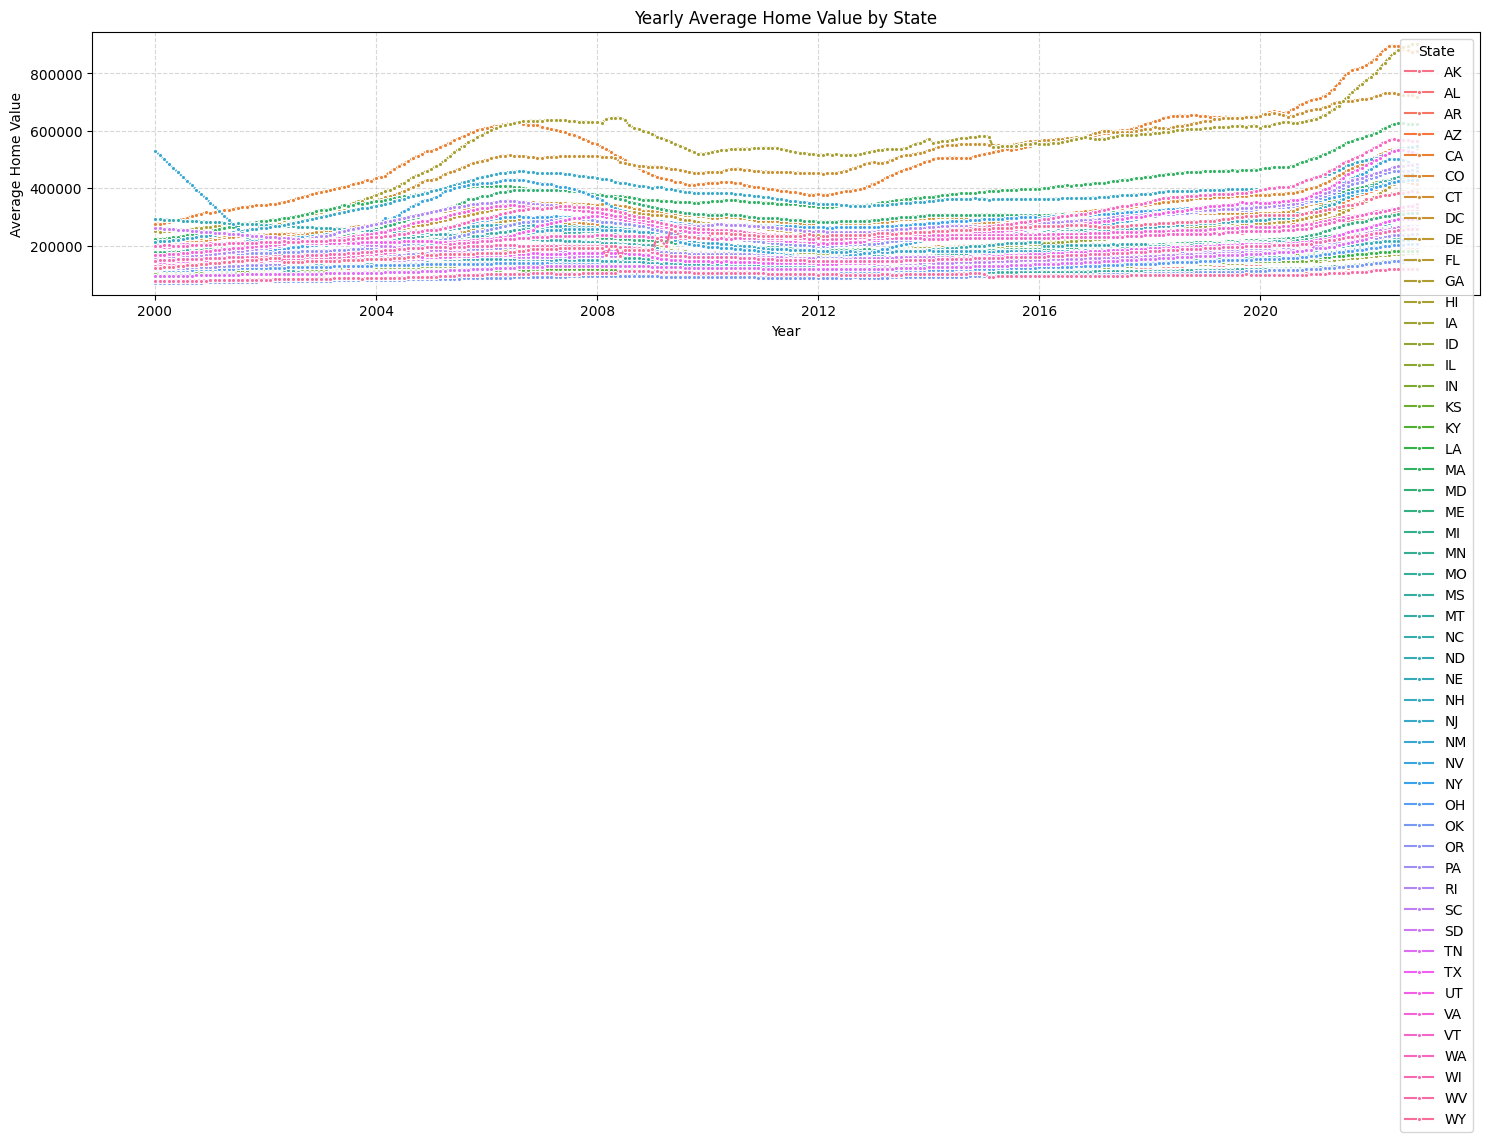

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the yearly_data Series back to a DataFrame for easier plotting
yearly_df = yearly_data.reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(data=yearly_df, x='Date', y='Home value', hue='State', marker='.')

plt.title('Yearly Average Home Value by State')
plt.xlabel('Year')
plt.ylabel('Average Home Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='State')
plt.tight_layout()
plt.show()

## Part 2

* Customed Functions

In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = mean_squared_error(ts_true, ts_pred, squared=False)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [ ]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np # Import numpy for sqrt function

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse) # Fixed: calculate RMSE by taking the square root of MSE
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

* Data of Oregon state form 2000 to 2018

In [ ]:
oregon_data = melted[melted['State'] == 'OR'].copy()
oregon_monthly_mean = oregon_data.loc['2000-01-31':'2018-12-31'].resample('MS')['Home value'].mean()
oregon_monthly_mean.head()

,Home value
Date,
2000-01-01,162508.613445
2000-02-01,162913.172269
2000-03-01,163011.125523
2000-04-01,163541.908333
2000-05-01,164176.420833


In [ ]:
oregon_monthly_mean.isna().sum()

np.int64(0)

* Decompose Seasonality

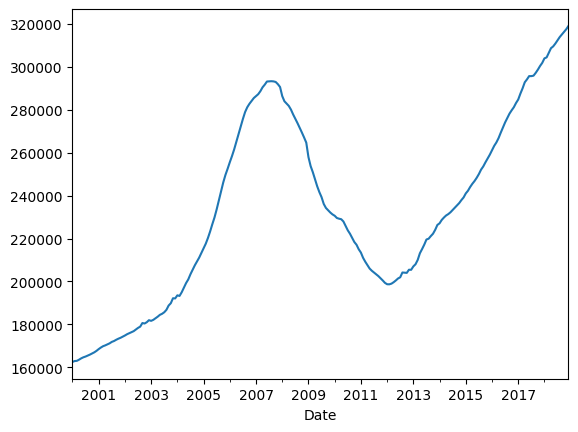

In [ ]:
oregon_monthly_mean.plot();

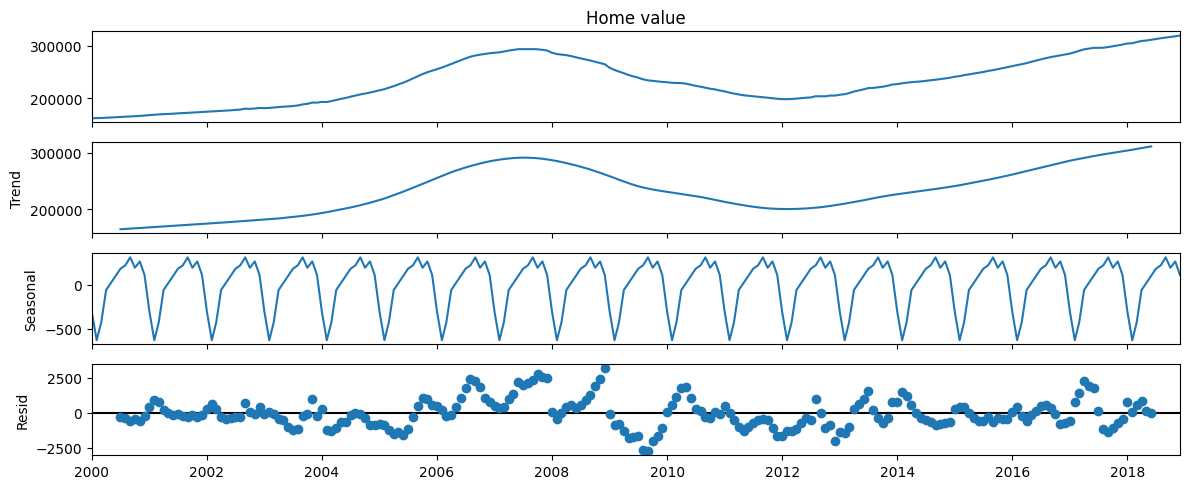

In [ ]:
# We see a repeating pattern that is likely seasonal
# Apply seasonal decomposition
decomp = tsa.seasonal_decompose(oregon_monthly_mean)
fig = decomp.plot()
fig.set_size_inches(12,5)
fig.tight_layout()

0.61% Variation in this time series could possibly adress that this data is notseasonal but after looking for the decompose seasonal its abviously shows a season every 12 months

In [ ]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta} which is ~{seasonal_delta/(oregon_monthly_mean.max()-oregon_monthly_mean.min()) * 100 :.2f}% of the variation in time series.")

The seasonal component is 948.4277802214281 which is ~0.61% of the variation in time series.


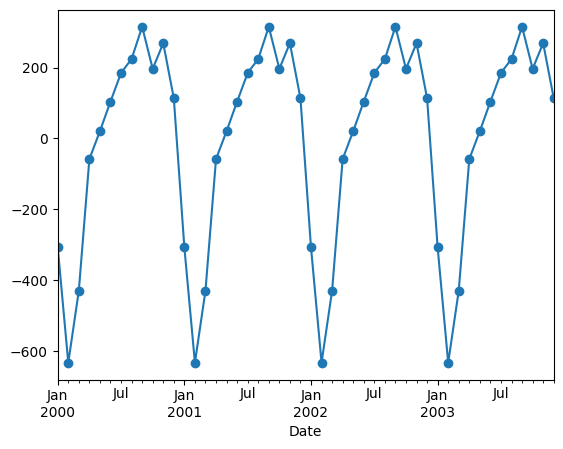

In [ ]:
# Narrow down the date range of the plot
seasonal = decomp.seasonal
ax = seasonal.loc['2000': '2003'].plot(marker = 'o')

* Data needs to be Stationary first

In [ ]:
# Call custom function to check to see if data is stationary
get_adfuller_results(oregon_monthly_mean)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


In [ ]:
# determine d
d = ndiffs(oregon_monthly_mean)
print (f'd = {d}')

d = 2


In [ ]:
# Determine D
D = nsdiffs(oregon_monthly_mean, m =12)
print(f'D = {D}')

D = 0


In [ ]:
# Difference the data
ts_diff = oregon_monthly_mean.diff().diff().dropna()
get_adfuller_results(ts_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-13.956007,1,224,0.0,0.05,True


* ACF and PACF plots here shows a decrease is the seasonal lags the same range
so we will start out model with 1 and 1 for Q&P


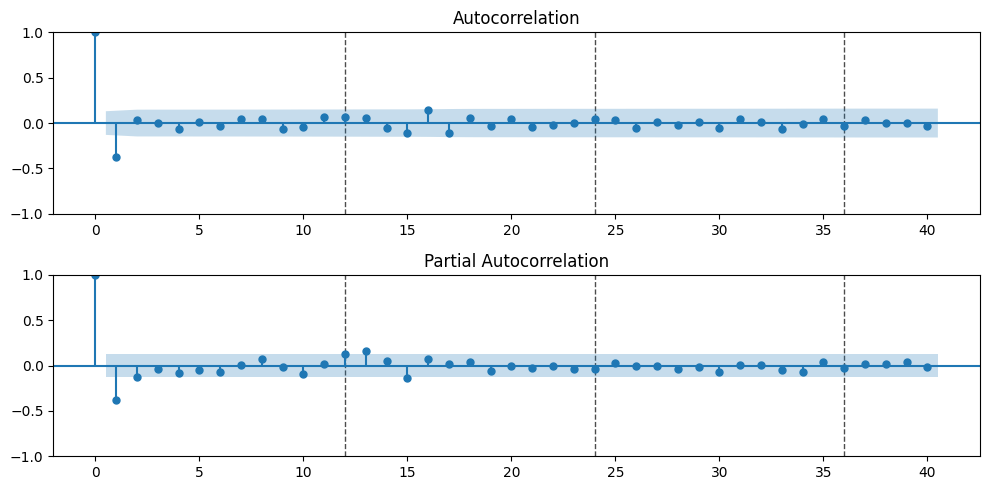

In [ ]:
plot_acf_pacf(ts_diff, annotate_seas=True, m = 12);

* Train Test Split the test set represents 12 months (the last year)

In [ ]:
# Split data into training and test sets
test_size = 12
train = oregon_monthly_mean.iloc[:-test_size]
test = oregon_monthly_mean.iloc[-test_size:]

print(f"Training data length: {len(train)}")
print(f"Test data length: {len(test)}")
print(f"Test start date: {test.index.min()}")
print(f"Test end date: {test.index.max()}")

Training data length: 216
Test data length: 12
Test start date: 2018-01-01 00:00:00
Test end date: 2018-12-01 00:00:00


In [ ]:
# Orders for non seasonal components
p = 2  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                       Home value   No. Observations:                  216
Model:             ARIMA(2, 2, 1)x(1, 0, 1, 12)   Log Likelihood               -1725.670
Date:                          Thu, 23 Apr 2026   AIC                           3463.339
Time:                                  09:06:34   BIC                           3483.535
Sample:                              01-01-2000   HQIC                          3471.500
                                   - 12-01-2017                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4027      2.458      0.164      0.870      -4.416       5.221
ar.L2         -0.0073      0.064     -0.115      0.909      -0.132       0.118
ma.L1         -0.4233      2.457     -0.172      0.863      -5.239       4.392
ar.S.L12       0.0527      9.622      0.005      0.996     -18.805      18.910
ma.S.L12      -0.0459      9.626     -0.005      0.996     -18.912      18.820
sigma2      5.153e+05   2.72e+04     18.926      0.000    4.62e+05    5.69e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.57   Jarque-Bera (JB):               358.08
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.31   Skew:                            -1.16
Prob(H) (two-sided):                  0.26   Kurtosis:                         8.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

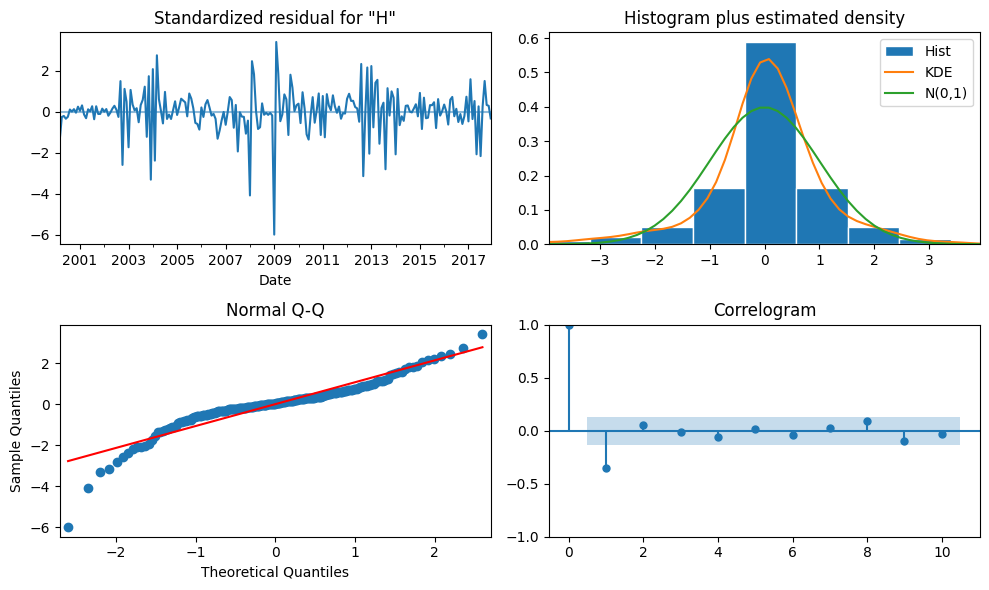

In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 379.747
- MSE = 202,520.085
- RMSE = 450.022
- R^2 = 0.991
- MAPE = 0.12%


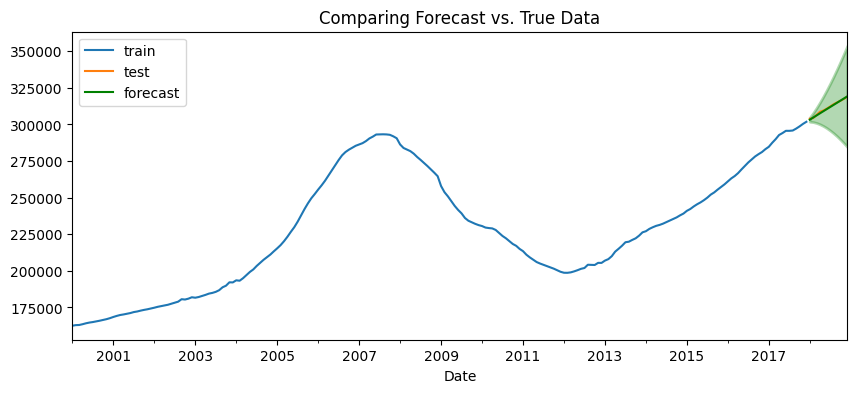

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

* Auto-Arima

In [ ]:
import pmdarima as pm

# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=4016.508, Time=1.33 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3822.254, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3823.629, Time=0.47 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3816.219, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3848.225, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=3817.779, Time=0.07 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=3818.217, Time=0.31 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=3817.994, Time=0.71 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=3816.230, Time=0.28 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=3819.930, Time=1.43 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=3820.431, Time=0.10 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=3785.579, Time=1.82 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=3798.715, Time=0.35 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.32 sec
 ARIMA(1,1,1)(0,0,2)[12]

In [ ]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(1, 1, 1)
(0, 0, 1, 12)


In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  216
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood               -1887.790
Date:                            Thu, 23 Apr 2026   AIC                           3785.579
Time:                                    09:07:00   BIC                           3802.432
Sample:                                01-01-2000   HQIC                          3792.389
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      7.9481     12.928      0.615      0.539     -17.390      33.287
ar.L1          0.9484      0.024     40.061      0.000       0.902       0.995
ma.L1         -0.9231      0.026    -35.355      0.000      -0.974      -0.872
ma.S.L12      -0.0013      0.028     -0.048      0.962      -0.056       0.054
sigma2      2.345e+06   9.65e-05   2.43e+10      0.000    2.35e+06    2.35e+06
===================================================================================
Ljung-Box (L1) (Q):                 163.25   Jarque-Bera (JB):                22.45
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.60   Skew:                            -0.65
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.48e+27. Standard errors may be unstable.
"""

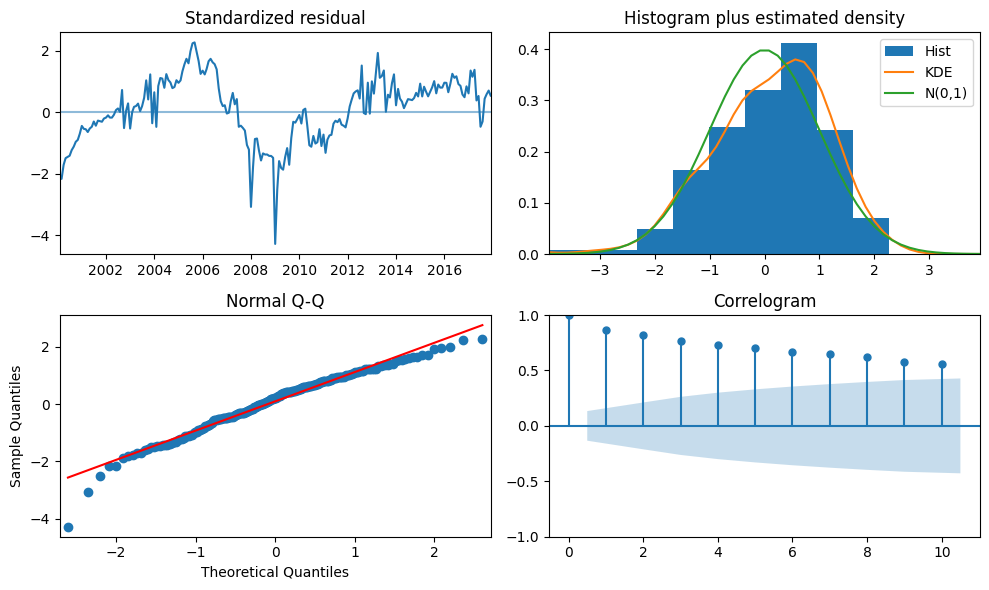

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 7,314.200
- MSE = 67,975,679.905
- RMSE = 8,244.736
- R^2 = -1.919
- MAPE = 2.33%


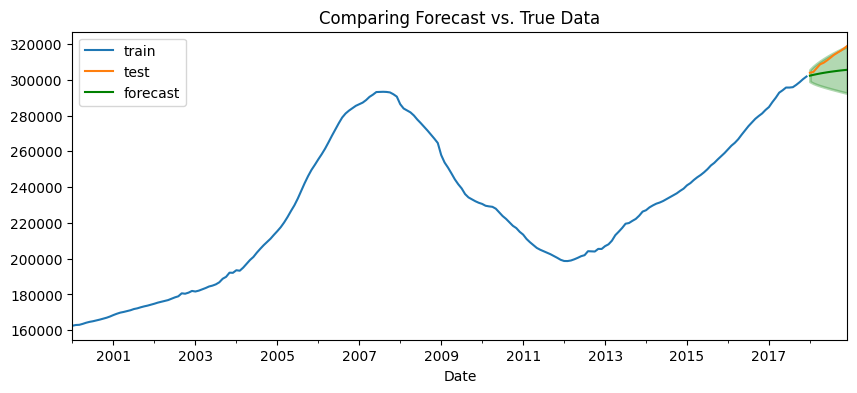

In [ ]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# Comparing the two models

-------------------------
Regression Metrics: Auto-Arima
-------------------------
- MAE = 7,314.200
- MSE = 67,975,679.905
- RMSE = 8,244.736
- R^2 = -1.919
- MAPE = 2.33%
------------------------------------------------------------
Regression Metrics: Manual
------------------------------------------------------------
- MAE = 379.747
- MSE = 202,520.085
- RMSE = 450.022
- R^2 = 0.991
- MAPE = 0.12%

comparing these two metrics we can defintly demonstrate that the manual model fit better on the data in every respect

This is lead us to conclude that SARIMA (2,2,1)(1,0,1)[12] IS the best model representing this data

### Forecasting True Future Values

In [ ]:
oregon = melted[melted['State'] == 'OR'].copy()
oregon_monthly = oregon.resample('MS')['Home value'].mean()
oregon_monthly.head()

,Home value
Date,
2000-01-01,162508.613445
2000-02-01,162913.172269
2000-03-01,163011.125523
2000-04-01,163541.908333
2000-05-01,164176.420833


In [ ]:
oregon_monthly.isna().sum()

np.int64(0)

In [ ]:
# train test split
test_size = 12
train = oregon_monthly.iloc[:-test_size]
test = oregon_monthly.iloc[-test_size:]

In [ ]:
final_p = 2
final_q = 2
final_d = 1
final_P = 1
final_Q = 0
final_D = 1

final_model = tsa.ARIMA(
    oregon_monthly,
    order=(final_p, final_d, final_q),
    seasonal_order=(final_P, final_D, final_Q, m),
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Comparing Forecast vs. True Data'}, xlabel='Date'>)

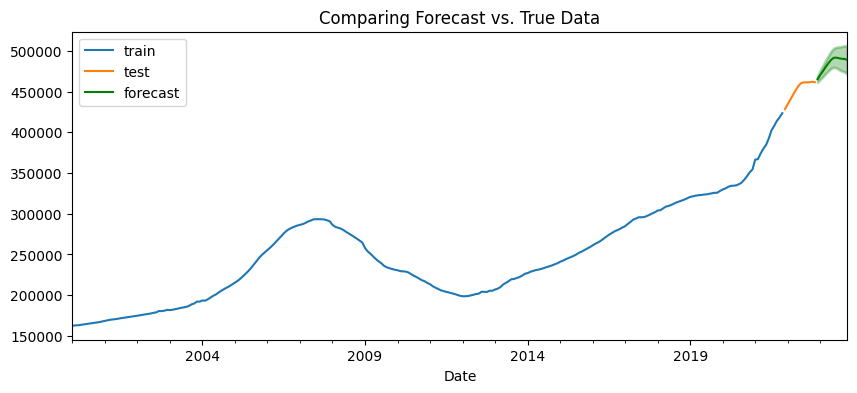

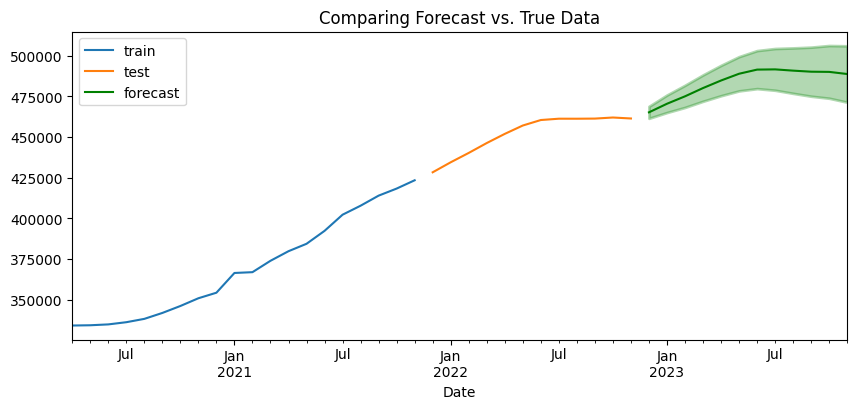

In [ ]:
# Generate forecast into the true future (model was fit on entire time series)
forecast_df = final_model.get_forecast(steps=len(test)).summary_frame()

plot_forecast(train, test, forecast_df, n_train_lags=1000)
plot_forecast(train, test, forecast_df, n_train_lags=20)

In [ ]:
# Define starting and final values
starting_value = forecast_df['mean'].iloc[0]
final_value = forecast_df['mean'].iloc[-1]
# Change in x
delta = final_value - starting_value
print(f'The change in X over the forecast is {delta: .2f}.')
perc_change = (delta/starting_value) *100
print (f'The percentage change is {perc_change :.2f}%.')

The change in X over the forecast is  23539.70.
The percentage change is 5.06%.


The predicted average home value in the final month of the forecast (November 2023) is approximately $488,686.61.


The percentage change in average home value over the entire 12-month forecast period is 5.06%.

# Tableau Workbook

https://public.tableau.com/app/profile/nara.daibes/viz/HomeValues_17767994754590/Story1?publish=yes